<a href="https://colab.research.google.com/github/Umair-127/LAB_WORK/blob/main/WEEK12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1 - Read a dataset and implement a basic classification model.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.DataFrame({
    "hours_study": [1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,1,2,3,4],
    "attendance": [50,60,65,70,75,80,85,90,55,62,68,72,78,82,88,92,48,58,66,74],
    "sleep_hours": [5,6,6,7,6,7,7,8,5,6,6,7,6,7,7,8,5,6,6,7],
    "result": [
        "Fail","Fail","Fail","Pass","Pass","Pass","Pass","Pass",
        "Fail","Fail","Pass","Pass","Pass","Pass","Pass","Pass",
        "Fail","Fail","Fail","Pass"
    ]
})

df["result"] = df["result"].map({"Fail":0, "Pass":1})

X = df[["hours_study","attendance","sleep_hours"]]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Actual Vlaue : ",y_test)
print("Predicted Value : ",y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))

Actual Vlaue :  19    1
12    1
1     0
10    1
15    1
Name: result, dtype: int64
Predicted Value :  [1 1 0 0 1]
Accuracy: 0.8


Question 2 - Generate and interpret a confusion matrix. Calculate accuracy, precision, recall, and F1-
score and visualize classification results.


[[ 5  1]
 [ 0 18]]
0.9583333333333334
0.9473684210526315
1.0
0.972972972972973


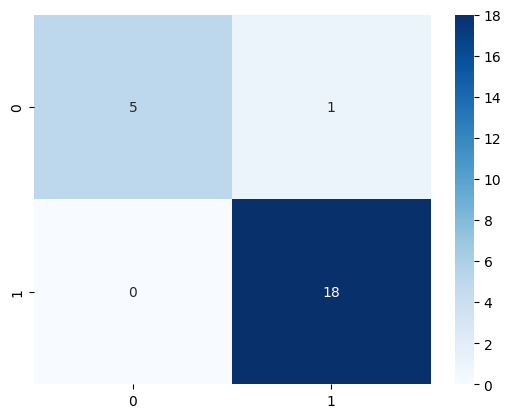

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
n = 120

df = pd.DataFrame({
    "hours_study": np.random.randint(1, 10, n),
    "attendance": np.random.randint(45, 96, n),
    "sleep_hours": np.random.randint(4, 9, n)
})

score = 5*df["hours_study"] + 0.5*df["attendance"] + 2*df["sleep_hours"] + np.random.randint(-10, 11, n)
df["result"] = (score >= 60).astype(int)

df.fillna(df.mean(), inplace=True)

X = df[["hours_study","attendance","sleep_hours"]]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

Question 3 - Use various classification models and compare them on the same datasets

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.DataFrame({
    "hours_study": [1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,1,2,3,4],
    "attendance": [50,60,65,70,75,80,85,90,55,62,68,72,78,82,88,92,48,58,66,74],
    "sleep_hours": [5,6,6,7,6,7,7,8,5,6,6,7,6,7,7,8,5,6,6,7],
    "result": [
        "Fail","Fail","Fail","Pass","Pass","Pass","Pass","Pass",
        "Fail","Fail","Pass","Pass","Pass","Pass","Pass","Pass",
        "Fail","Fail","Fail","Pass"
    ]
})

df["result"] = df["result"].map({"Fail":0, "Pass":1})

X = df[["hours_study","attendance","sleep_hours"]]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Logistic": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Accuracy: 1.0
DecisionTree Accuracy: 1.0
KNN Accuracy: 0.75
